In [2]:
import numpy as np
import matplotlib.pyplot as plt

import astropy.units as u
from config.plotting import set_plotting_defaults, royalblue_palette, orangered_palette, save_figure

set_plotting_defaults()


In [3]:
def calculate_width(angle, if_plot = False, ax = None):
    error = 0.035  # [deg]

    length = 0.977 / np.sin(np.deg2rad(angle))  # [deg]

    width = np.array([0.318, 0.210, 0.254, 0.286, 0.275])

    l_min, l_max = length - error, length + error
    w_min, w_max = width - error, width + error

    r_min, r_max = l_min / w_max, l_max / w_min
    r_mean = 0.5 * (r_min + r_max)
    delta = 0.5 * (r_max - r_min)

    mean = np.average(r_mean, weights=delta**(-2))
    std = np.sum(delta**(-2))**(-0.5)
    print(f"width = {mean:.2f} pm {std:.2f}", end='  ')

    if if_plot and ax is not None:
        for i, w in enumerate(width):
            ax.errorbar(r_mean[i], [4-i], xerr=delta[i], capsize=5, capthick=2, marker='o', elinewidth=2)

        ax.plot([mean, mean], [-1, 6], color='black', linestyle='dashed', linewidth=2)
        ax.fill_betweenx([-1, 6], [mean-std, mean-std], [mean+std, mean+std],
                          color='slategray', alpha=0.2, linewidth=0)

        ax.set_ylim(-0.5, 4.5)

        ax.set_yticks([0, 1, 2, 3, 4], ["S", "SC", "CS", "C", "N"])

    return mean, std

width = 3.56 pm 0.26  

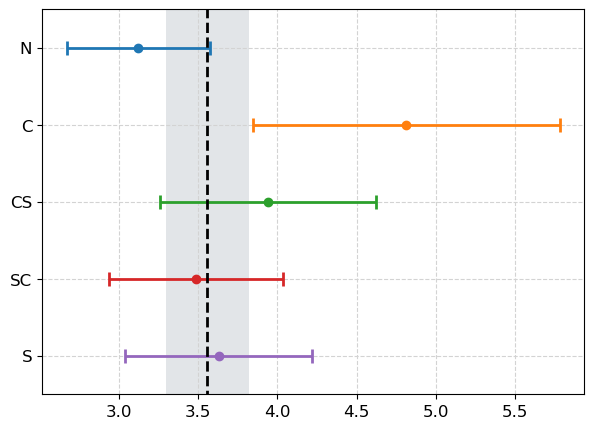

In [4]:
mean0, std0 = calculate_width(90*u.deg, if_plot=True, ax=plt.gca())

Size:
$$ L_\parallel = \sqrt{4D_\parallel t},\quad L_\bot = \sqrt{4D_\bot t} $$
$$ \dfrac{D_\parallel}{D_\bot} = \left(\dfrac{L_\parallel}{L_\bot}\right)^2 = 3.56^2 = 12.7 $$

Diffusion coefficient as a function of field ratio

In [5]:
eta = np.array([0.1, 0.5, 1, 2, 4, 100])

d1 = np.array([1.1873147505014567e+32, 2.7428504812182430e+30,
               8.0353546391545170e+29, 2.9089654731970035e+29,
               1.5415114657448823e+29, 1.0094517250214808e+29])

d2 = np.array([1.9411057738657806e+27, 1.0407935521169378e+28,
               2.7171685512349550e+28, 5.9885766995195910e+28,
               8.4025853154443460e+28, 1.0094517250214808e+29])

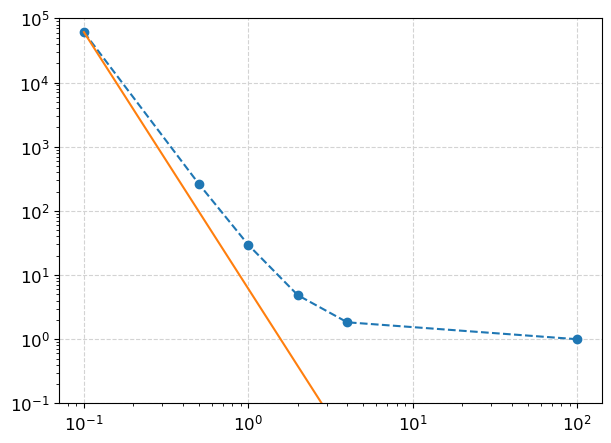

In [6]:
plt.loglog(eta, d1/d2, marker='o', linestyle='dashed')
plt.plot(eta, (d1/d2)[0] * (eta/eta[0])**(-4))
plt.ylim(1e-1, 1e5)
plt.show()

In [7]:
def get_ratio_values(mean, std, if_plot = False, ax = None):

    x1 = np.log10(1+1/eta)
    y1 = np.log10(d1/d2)

    pf = np.polyfit(y1, x1, 1)
    f1 = np.poly1d(pf)

    if if_plot and ax is not None:
        ax.scatter(1+1/eta, d1/d2, color='black', linestyle='dashed')
        ax.plot(1+1/eta, d1/d2, color='black', linestyle='solid', linewidth=1)

        y2 = np.linspace(0, 5, 1000)
        print(1/pf[0])
        ax.plot(10**f1(y2), 10**y2, color='orangered', linestyle='dashed', label='a power-law fit, p=4.8')

        ax.set_xscale('log')
        ax.set_xlabel(r'$\lg(1+1/\eta)$')

        ax.set_yscale('log')
        ax.set_ylabel(r'$D_\parallel/D_\bot$')

        ax.set_xticks([1, 1.25, 1.5, 2, 3, 11],
                      [1, 1.25, 1.5, 2, 3, 11])

        ax.legend()

    width2 = mean**2
    width_low2 = (mean-std)**2
    width_high2 = (mean+std)**2

    log_width2 = np.log10(width2)
    log_width_low2 = np.log10(width_low2)
    log_width_high2 = np.log10(width_high2)

    ratio = 10**f1(log_width2) - 1
    ratio_min = 10**f1(log_width_low2) - 1
    ratio_max = 10**f1(log_width_high2) - 1

    print(f"MIN: B_|| / B_bot = {ratio_min:.2f}", end='  ')
    print(f"MEAN: B_|| / B_bot = {ratio:.2f}", end='  ')
    print(f"MAX: B_|| / B_bot = {ratio_max:.2f}")

    return ratio, ratio_min, ratio_max

4.763625682352741
MIN: B_|| / B_bot = 0.70  MEAN: B_|| / B_bot = 0.75  MAX: B_|| / B_bot = 0.81


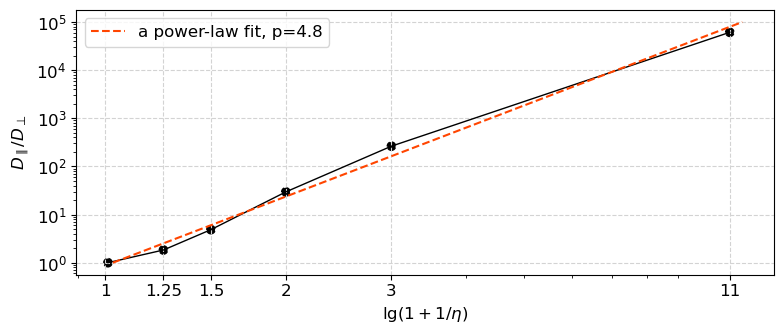

In [8]:
plt.figure(figsize=(8, 3.5))
ratio0, ratio_min0, ratio_max0 = get_ratio_values(mean0, std0, if_plot = True, ax=plt.gca())

plt.tight_layout()
save_figure("diffusion-ratio-powerlaw")

Various angles

In [9]:
angles = np.array([90, 60, 40, 16, 5]) * u.deg
print(1 / np.sin(angles))

[ 1.          1.15470054  1.55572383  3.62795528 11.47371325]


width = 3.56 pm 0.26  MIN: B_|| / B_bot = 0.70  MEAN: B_|| / B_bot = 0.75  MAX: B_|| / B_bot = 0.81
width = 4.10 pm 0.30  MIN: B_|| / B_bot = 0.80  MEAN: B_|| / B_bot = 0.86  MAX: B_|| / B_bot = 0.92
width = 5.52 pm 0.38  MIN: B_|| / B_bot = 1.05  MEAN: B_|| / B_bot = 1.11  MAX: B_|| / B_bot = 1.17
width = 12.81 pm 0.80  MIN: B_|| / B_bot = 1.92  MEAN: B_|| / B_bot = 2.00  MAX: B_|| / B_bot = 2.08
width = 40.43 pm 2.41  MIN: B_|| / B_bot = 3.74  MEAN: B_|| / B_bot = 3.87  MAX: B_|| / B_bot = 3.99
width = 2017.01 pm 117.46  MIN: B_|| / B_bot = 23.50  MEAN: B_|| / B_bot = 24.12  MAX: B_|| / B_bot = 24.73
width = 200.13 pm 11.71  MIN: B_|| / B_bot = 8.29  MEAN: B_|| / B_bot = 8.52  MAX: B_|| / B_bot = 8.75
width = 105.32 pm 6.19  MIN: B_|| / B_bot = 6.09  MEAN: B_|| / B_bot = 6.27  MAX: B_|| / B_bot = 6.45
width = 71.49 pm 4.22  MIN: B_|| / B_bot = 5.03  MEAN: B_|| / B_bot = 5.18  MAX: B_|| / B_bot = 5.33
width = 54.12 pm 3.21  MIN: B_|| / B_bot = 4.36  MEAN: B_|| / B_bot = 4.50  MAX: B_|

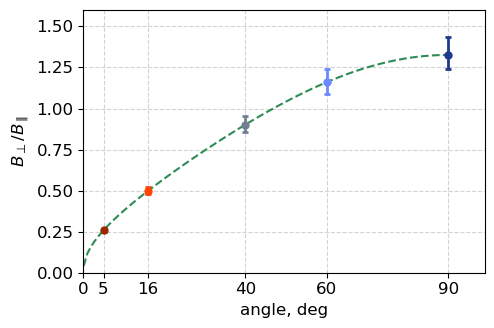

In [10]:
plt.figure(figsize=(5, 3.5))
colors = [royalblue_palette[2], royalblue_palette[0], 'slategray', orangered_palette[1], orangered_palette[3]]

for i, a in enumerate(angles):
    mean_a, std_a = calculate_width(a, if_plot = False)
    ratio_a, ratio_min_a, ratio_max_a = get_ratio_values(mean_a, std_a, False)
    plt.errorbar([a.value], [1/ratio_a], yerr=[[-1/ratio_max_a + 1/ratio_a], [-1/ratio_a + 1/ratio_min_a]],
                 capsize=2, capthick=2, marker='o', markersize=5, elinewidth=2, color=colors[i])

angles2 = np.linspace(0.1, 90, 100) * u.deg
ratios = []
for j, a in enumerate(angles2):
    mean_a, std_a = calculate_width(a, if_plot = False)
    ratio_a, _, _ = get_ratio_values(mean_a, std_a, False)
    ratios.append(ratio_a)

plt.plot(angles2, 1/np.array(ratios), color='seagreen', linestyle='dashed')

plt.xlabel("angle, deg")
plt.xlim(0, 99)

plt.ylabel(r"$B_\bot / B_\parallel$")
# plt.yscale('log')
plt.xticks([0, 5, 16, 40, 60, 90])
plt.ylim(0.0, 1.6)
plt.tight_layout()

save_figure("mf_ratio")
plt.show()